In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })

In [3]:
theta = np.linspace(0, np.pi, 20)
vel_wind = np.linspace(0.02, 0.1, 30)
vel_dyn1 = np.linspace(0.1, 0.4, 30)
vel_dyn2 = np.linspace(0.4, 0.65, 30)



In [23]:
def vmax_wind(v_ej_wind, v_min = 0.02):

    res = optimize.brentq(lambda x: (x-v_min) / np.log(x/v_min) - v_ej_wind, 1e-3, 1.)

    return res

def find_vmax_dyn(v_ej_dyn, vmin=0.1, vmid=0.4):

    if v_ej_dyn <= np.log(vmid/vmin) / (1/vmin-1/vmid):
        def eq(x):
            out = np.log(x/vmin)
            out /= vmin**(-1) - x**(-1)
            return out - v_ej_dyn
        res = optimize.brentq(eq, 0.11, 0.4)
    
    else:
        def eq(x):
            out = np.log(vmid/vmin) + (vmid**(-4)-x**(-4)) / 4
            out /= (vmin**(-1)- vmid**(-1) ) + ( vmid**(-5) - x**(-5) ) / 5
            return out - v_ej_dyn
        res = optimize.brentq(eq, 0.4, 1)
        
    return res

0.5073321479993866

In [19]:
vmin = 0.1
vmid = 0.4

def eq(x):
        out = np.log(vmid/vmin) + (vmid**(-4)-x**(-4)) / 4
        out /= (1/vmin-1/vmid) + (vmid**(-5) - x**(-5)) / 5
        return out

In [20]:
np.log(vmid/vmin) / (1/vmin-1/vmid)

np.float64(0.18483924814931874)

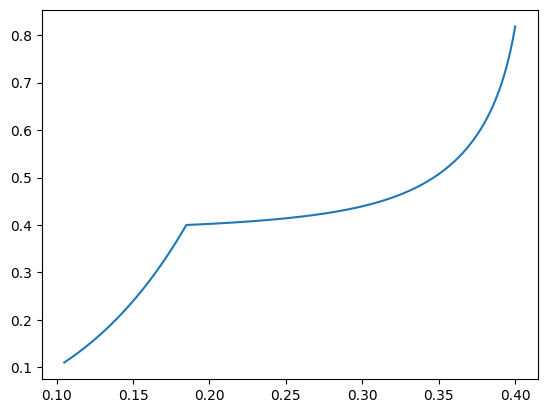

In [29]:
x = np.linspace(0.105, 0.4, 1000)

plt.plot(x, [find_vmax_dyn(xx) for xx in x])
#plt.ylim((0.1, 0.4))

In [14]:
find_vmax_dyn(0.19)

0.40075787586834344

In [67]:
def dyn_mass_segment(v0, v1, theta0=0, theta1=np.pi):
        v0 = min( max(0.1, v0), 0.4023562064375284)
        v1 = min( max(0.1, v1), 0.4023562064375284)
        rho0_dyn = 0.0001480012103430451
        if v1 <= 0.4:
            radial_factor = rho0_dyn * (1/v0 - 1/v1)
        elif v0 < 0.4 and v1 > 0.4:
            radial_factor = rho0_dyn * ( (1/v0 - 1/0.4) + 0.4**4 *(0.4**(-5) - v1**(-5) ) / 5 )
        elif v0 >= 0.4:
            radial_factor = rho0_dyn * 0.4**4 * (v0**(-5) - v1**(-5)) / 5
        
        angular_factor = 2*np.pi * (np.cos(theta1)**3 / 3 - np.cos(theta1) - np.cos(theta0)**3 / 3 + np.cos(theta0))

        return radial_factor * angular_factor


def density(v1):
     
    if v1< 0.4:
        return v1**(-4)
    else:
        return v1**(-8) * 0.4**(-4) / 0.4**(-8)


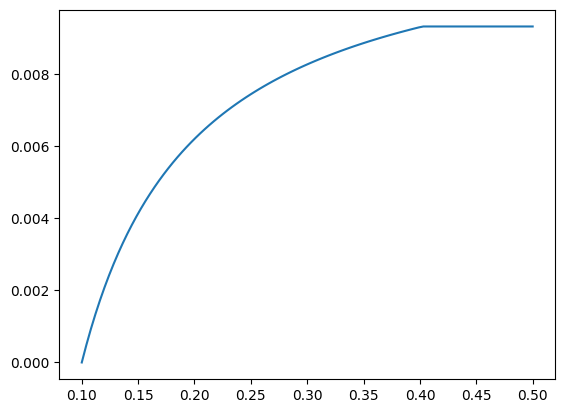

In [68]:
x = np.linspace(0.1, 0.5, 100)
mass = [dyn_mass_segment(0.1, xx) for xx in x]

plt.plot(x, mass)

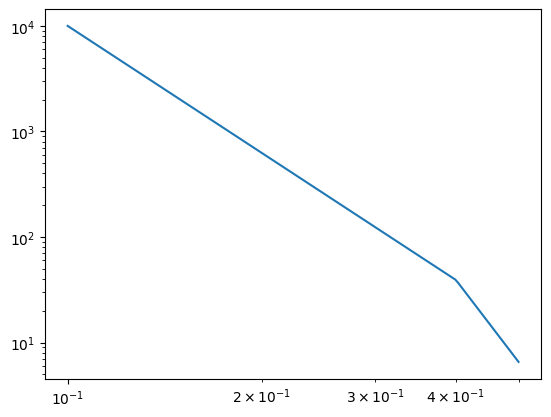

In [54]:
x = np.linspace(0.1, 0.5, 100)
dens = [density(xx) for xx in x]

plt.loglog(x, dens)

In [105]:
def eq(x):
            vmid = 0.4
            vmin = 0.1

            out = np.log(vmid/vmin) + 0.4**4 * (vmid**(-4)-x**(-4)) / 4
            out /= (vmin**(-1)- vmid**(-1) ) + 0.4**4 * ( vmid**(-5) - x**(-5) ) / 5
            return out

def eq_possis(x):

            vmid = 0.4
            vmin = 0.1
            
            c = np.log(vmid/vmin)
            f = ((x/vmid)**(-4) - 1) / -4
            d = vmid/vmin - 1
            g = ((x/vmid)**-5 -1) / -5

            out = vmid * (c+f) / (d+g)
            return out

def eq_low(x):
            vmin = 0.1
            out = np.log(x/vmin)
            out /= vmin**(-1) - x**(-1)
            return out


x = np.linspace(0.4, 0.9, 100)
y = eq(x)
y_possis = eq_possis(x)

ylow = eq_low(np.linspace(0.1, 0.4, 100))

/tmp/ipykernel_44271/832498575.py:25: RuntimeWarning: invalid value encountered in divide
  out /= vmin**(-1) - x**(-1)


In [2]:
def find_vmax_dyn(v_ej_dyn, vmin=0.1, vmid=0.4):

    if v_ej_dyn <= np.log(vmid/vmin) / (1/vmin-1/vmid):
        def eq(x):
            out = np.log(x/vmin)
            out /= vmin**(-1) - x**(-1)
            return out - v_ej_dyn
        res = optimize.brentq(eq, 0.11, 0.4)
    
    else:
        def eq(x):
            out = np.log(vmid/vmin) + 0.4**4 * (vmid**(-4)-x**(-4)) / 4
            out /= (vmin**(-1)- vmid**(-1) ) + 0.4**4 * ( vmid**(-5) - x**(-5) ) / 5
            return out - v_ej_dyn
        
        try:
            res = optimize.brentq(eq, 0.4, 0.9)
        except ValueError:
            res = 0.9
        
    return res


def vaverage_of_vmax(x, vmin=0.1, vmid=0.4):
        
        c = np.log(vmid/vmin)
        f = ((x/vmid)**(-4) - 1) / -4
        d = vmid/vmin - 1
        g = ((x/vmid)**-5 -1) / -5
        
        if x<vmin:
            return np.nan

        elif x<=vmid:
            out = np.log(x/vmin) /(vmin**(-1) -x**(-1))
            return out
        elif x>vmid:
            out = vmid * (c+f) / (d+g)
            return out
        

def vaverage_of_vmin(x, vmax=0.9, vmid=0.4):
        
       
        if x>vmax:
            return np.nan

        elif x<=vmid:
            out = np.log(vmid/x) + vmid**4 *(vmid**(-4) - vmax**(-4)) / 4 
            out /= x**(-1) - vmid**(-1) + vmid**4 * (vmid**(-5)- vmax**(-5)) / 5
            return out
        elif x>vmid:
            out = (x**(-4) - vmax**(-4)) / 4 
            out /= (x**(-5)- vmax**(-5)) / 5
            return out
        
def vaverage_of_vmid(x, vmax=0.9, vmin=0.1):

    if x>vmax or x< vmin:
        return np.nan
    
    out = np.log(x/vmin) + x**4 *(x**(-4) - vmax**(-4)) / 4 
    out /= vmin**(-1) - x**(-1) + x**4 * (x**(-5)- vmax**(-5)) / 5

    return out
        
def vaverage_of_alpha1(alpha1, vmin=0.1, vmax=0.9, vmid=0.4):
    
    if alpha1 !=4:
        a = (vmid**(4-alpha1) - vmin**(4-alpha1)) / (4-alpha1)
    else:
        a = np.log(vmid/vmin)
    
    if alpha1!=3:
        c = (vmid**(3-alpha1) - vmin**(3-alpha1)) / (3-alpha1)
    else:
        c = np.log(vmid/vmin)

    b = vmid**(8-alpha1) *(vmid**(-4) - vmax**(-4)) / 4 
    d = vmid**(8-alpha1) * (vmid**(-5)- vmax**(-5)) / 5
    out = (a + b) / (c +d)
    return out



def vaverage_of_alpha2(alpha2, vmin=0.1, vmax=0.9, vmid=0.4):
    
    alpha1 = 4
    a = np.log(vmid/vmin)
    c = (vmid**(3-alpha1) - vmin**(3-alpha1)) / (3-alpha1)
    
    if alpha2 !=4:
        b = vmid**(alpha2-alpha1) *(vmax**(4-alpha2) - vmid**(4-alpha2)) / (4-alpha2)
    else:
        b = np.log(vmax/vmid)

    if alpha2 !=3:
        d = vmid**(alpha2-alpha1) * (vmax**(3-alpha2)- vmid**(3-alpha2)) / (3-alpha2)
    else:
        d = vmid**(alpha2-alpha1) * np.log(vmax/vmid)
    out = (a + b) / (c +d)
    return out

def vaverage_tim(alpha1, vmax=0.9, vmid=0.4):

    vmin = 0.2 - 0.05*(alpha1-2)
    
    if alpha1 !=4:
        a = (vmid**(4-alpha1) - vmin**(4-alpha1)) / (4-alpha1)
    else:
        a = np.log(vmid/vmin)
    
    if alpha1!=3:
        c = (vmid**(3-alpha1) - vmin**(3-alpha1)) / (3-alpha1)
    else:
        c = np.log(vmid/vmin)

    b = vmid**(8-alpha1) *(vmid**(-4) - vmax**(-4)) / 4 
    d = vmid**(8-alpha1) * (vmid**(-5)- vmax**(-5)) / 5
    out = (a + b) / (c +d)
    return out


/tmp/ipykernel_23945/121449731.py:35: RuntimeWarning: invalid value encountered in scalar divide
  out = np.log(x/vmin) /(vmin**(-1) -x**(-1))


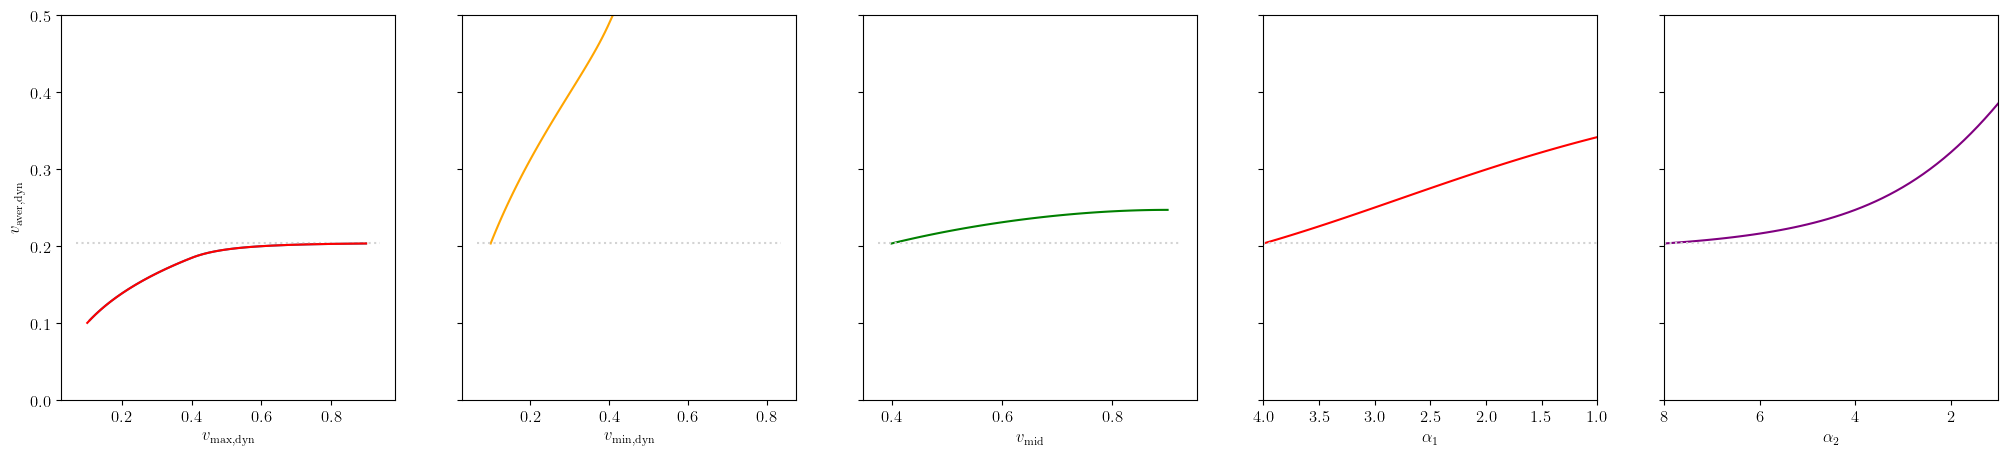

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

x = np.linspace(0.1, 0.9, 100)
ax[0].plot(x, np.vectorize(vaverage_of_vmax)(x), label="vmax_variable")
ax[0].hlines(vaverage_of_vmax(0.9), *ax[0].get_xlim(), linestyle="dotted", color="lightgrey")
ax[0].set_xlabel("$v_{\\rm{max, dyn}}$")
ax[0].set_ylabel("$v_{\\rm{aver, dyn}}$")
ax[0].set_ylim((0, 0.5))

x = np.linspace(0.1, 0.8, 100)
ax[1].plot(x, np.vectorize(vaverage_of_vmin)(x), label="vmin_variable", color="orange")
ax[1].set_xlabel("$v_{\\rm{min, dyn}}$")
ax[1].hlines(vaverage_of_vmax(0.9), *ax[1].get_xlim(), linestyle="dotted", color="lightgrey")

x = np.linspace(0.4, 0.9, 100)
ax[2].plot(x, np.vectorize(vaverage_of_vmid)(x), label="vmid_variable", color="green")
ax[2].set_xlabel("$v_{\\rm{mid}}$")
ax[2].hlines(vaverage_of_vmax(0.9), *ax[2].get_xlim(), linestyle="dotted", color="lightgrey")

x = np.linspace(1, 4, 50)
ax[3].plot(x, np.vectorize(vaverage_of_alpha1)(x), label="alpha1_variable", color="red")
ax[3].set_xlabel("$\\alpha_1$")
ax[3].set_xlim((4, 1))
ax[3].hlines(vaverage_of_vmax(0.9), *ax[3].get_xlim(), linestyle="dotted", color="lightgrey")


x = np.linspace(1, 8, 50)
ax[4].plot(x, np.vectorize(vaverage_of_alpha2)(x), label="alpha2_variable", color="purple")
ax[4].set_xlabel("$\\alpha_2$")
ax[4].set_xlim((8, 1))
ax[4].hlines(vaverage_of_vmax(0.9), *ax[4].get_xlim(), linestyle="dotted", color="lightgrey")


/tmp/ipykernel_37512/1665865200.py:35: RuntimeWarning: invalid value encountered in scalar divide
  out = np.log(x/vmin) /(vmin**(-1) -x**(-1))


(4.0, 2.5)

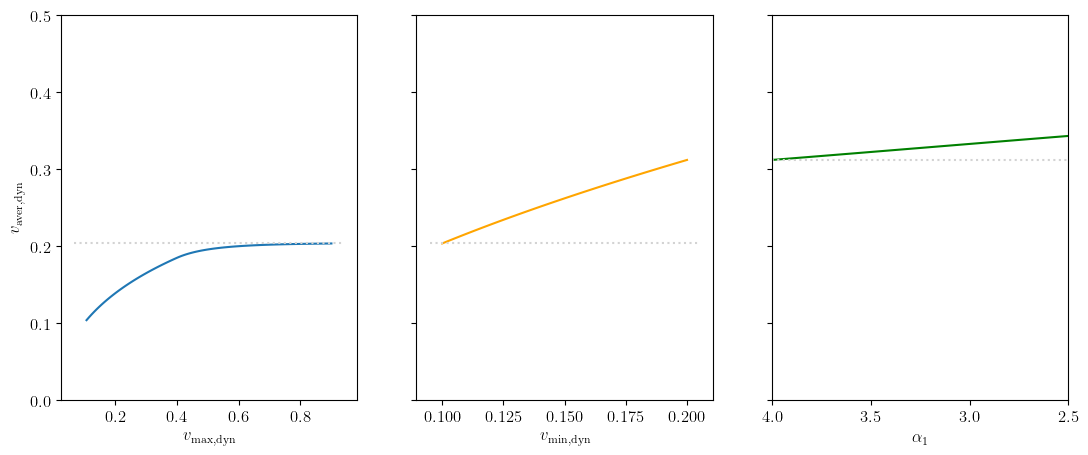

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 5), sharey=True)

x = np.linspace(0.1, 0.9, 100)
ax[0].plot(x, np.vectorize(vaverage_of_vmax)(x), label="vmax_variable")
ax[0].hlines(vaverage_of_vmax(0.9), *ax[0].get_xlim(), linestyle="dotted", color="lightgrey")
ax[0].set_xlabel("$v_{\\rm{max, dyn}}$")
ax[0].set_ylabel("$v_{\\rm{aver, dyn}}$")
ax[0].set_ylim((0, 0.5))

x = np.linspace(0.1, 0.2, 40)
ax[1].plot(x, np.vectorize(vaverage_of_vmin)(x), label="vmin_variable", color="orange")
ax[1].set_xlabel("$v_{\\rm{min, dyn}}$")
ax[1].hlines(vaverage_of_vmax(0.9), *ax[1].get_xlim(), linestyle="dotted", color="lightgrey")

x = np.linspace(2.5, 4, 50)
ax[2].plot(x, np.vectorize(vaverage_of_alpha1)(x, vmin=0.2), label="alpha1_variable", color="green")
ax[2].set_xlabel("$\\alpha_1$")
ax[2].hlines(vaverage_of_vmin(0.2), *ax[2].get_xlim(), linestyle="dotted", color="lightgrey")
ax[2].set_xlim((4, 2.5))


In [22]:
aa, vm = np.meshgrid(np.linspace(2, 4, 60), np.linspace(0.1, 0.2, 100))
y = np.vectorize(vaverage_of_alpha1)(aa, vmin=vm)

Text(0, 0.5, '$v_{\\rm{min, dyn}}$')

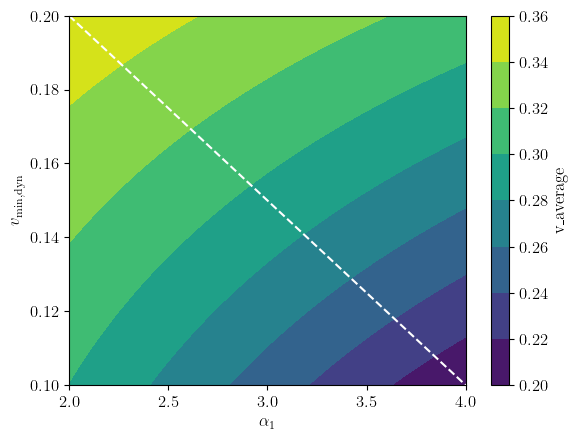

In [27]:
plt.contourf(aa, vm, y)
plt.colorbar(label="v_average")

plt.plot(np.linspace(2, 4, 10), 0.2-0.05*(np.linspace(2, 4, 10)-2), color="white", linestyle="dashed")
plt.xlabel("$\\alpha_1$")
plt.ylabel("$v_{\\rm{min, dyn}}$")

/tmp/ipykernel_23945/121449731.py:35: RuntimeWarning: invalid value encountered in scalar divide
  out = np.log(x/vmin) /(vmin**(-1) -x**(-1))


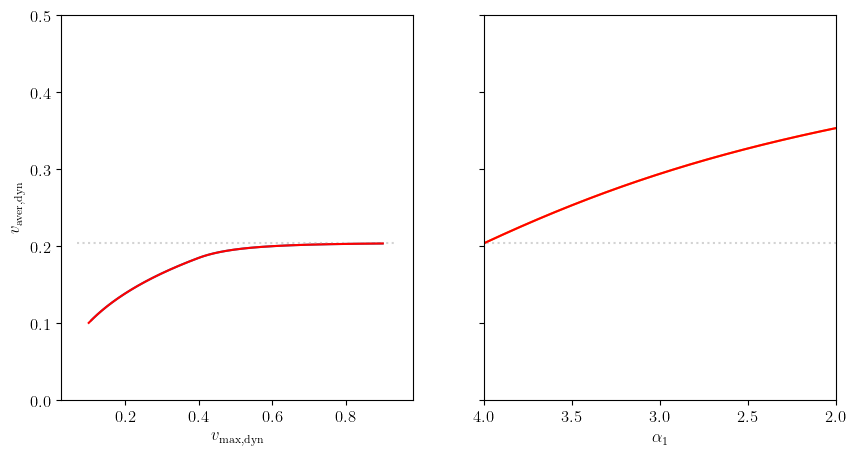

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

x = np.linspace(0.1, 0.9, 100)
ax[0].plot(x, np.vectorize(vaverage_of_vmax)(x), label="vmax_variable")
ax[0].hlines(vaverage_of_vmax(0.9), *ax[0].get_xlim(), linestyle="dotted", color="lightgrey")
ax[0].set_xlabel("$v_{\\rm{max, dyn}}$")
ax[0].set_ylabel("$v_{\\rm{aver, dyn}}$")
ax[0].set_ylim((0, 0.5))

x, y = np.loadtxt("possis_output.dat", unpack=True)
ax[0].plot(x, y, label="possis", color="red")

x = np.linspace(2, 4, 40)
ax[1].plot(x, np.vectorize(vaverage_tim)(x), label="tim", color="orange")
ax[1].set_xlabel("$\\alpha_1$")
ax[1].hlines(vaverage_of_vmax(0.9), *ax[1].get_xlim(), linestyle="dotted", color="lightgrey")
ax[1].set_xlim((4,2))

_, x, y = np.loadtxt("possis_output2.dat", unpack=True)
ax[1].plot(x, y, color="red")

In [35]:
vaverage_tim(2)

0.35331939362258236

In [16]:
np.interp(0.35, y[::-1], x[::-1])

np.float64(0.7663227174809586)

In [17]:
vaverage_of_alpha1(0.766322)

0.3500054172554896

In [ ]:
from fiesta.inference.lightcurve_model import BullaFlux
model = BullaFlux("Bu2026_MLP", filters=["sdssg"])

15:44 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
15:44 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
15:44 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
15:44 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
15:44 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.8860566476931632)
15:44 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
15:44 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
15:44 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
15:44 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
15:44 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['sdssg'].
15:44 fiesta INFO    : Loaded for surrogate Bu2026_MLP from /nfs/aya/work/hkoehn/fiesta/fiesta/src/fiesta/surrogates/KN/Bu2026_MLP/model.


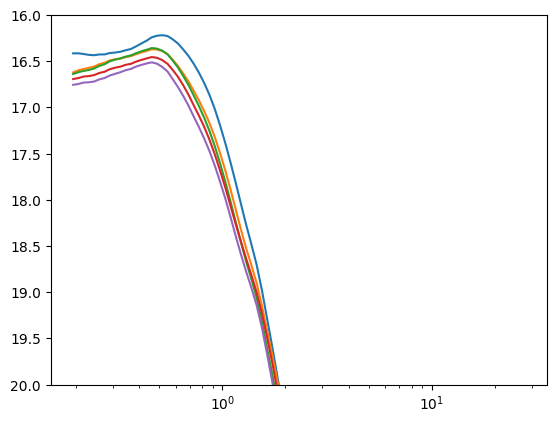

In [104]:
for vdyn in [0.20, 0.21, 0.22, 0.3, 0.35]:

    params = {"inclination_EM": 0, "log10_mej_dyn": -1.5, "v_ej_dyn": vdyn, "Ye_dyn": 0.3, "log10_mej_wind": -4, "v_ej_wind": 0.1, "Ye_wind": 0.2, "luminosity_distance": 40, "redshift": 0.}

    times, mags = model.predict(params)

    plt.plot(times, mags["sdssg"])

plt.ylim(20, 16)
plt.xscale("log")
